# Exploring the Data Lake

**Three zoom levels:**

| Level | Question | Tool | Cost |
|---|---|---|---|
| **Storage** | What files physically exist? | `s3_ls()` (boto3) | free |
| **Catalog** | What's registered as a queryable table? | `databases()`, `tables()`, `describe()` (Glue) | free |
| **Data** | What do the values look like? | `aq()` (Athena) or `dread()` (DuckDB) | small / local |

Note: If anything says *"token expired"*, run `aws sso login --profile ciccada` in a terminal and re-run the cell.

In [1]:
from aws_config import *
# confirm you're logged in
# if not, run "aws sso login --profile ciccada" in your terminal and try again
session.client('sts').get_caller_identity()['Arn']

'arn:aws:sts::130340360668:assumed-role/AWSReservedSSO_AWSAdministratorAccess_58ece215f84a4b54/z3553082_sa@ad.unsw.edu.au'

## Imports & declarations

In [2]:
import pandas as pd
# Show every single column
pd.set_option('display.max_columns', None)

## [Level 1] Storage: the physical files in S3

`s3_ls()` lists what's actually in the bucket. 

This is ground truth. Works even for data that isn't in Glue yet.

In [3]:
# Top level of the bucket. Major data areas
s3_ls()

,type,name,size_mb
0,folder,BOM_NCI/,None
1,folder,DeepArchive/,None
2,folder,Flask_App/,None
3,folder,PostgreJDBC_Driver/,None
4,folder,SAPN/,None
5,folder,SAPNTest/,None
6,folder,Trino-Warehouse/,None
7,folder,athena-results/,None
8,folder,spark-warehouse/,None
9,folder,temp_SolA/,None


In [4]:
# Inside the Spark warehouse is where results tables seem to be written
s3_ls('spark-warehouse/')

,type,name,size_mb
0,folder,spark-warehouse/Compliance_results_SolA/,None
1,folder,spark-warehouse/SolA_metadata/,None
2,folder,spark-warehouse/bucketed_table4_partitions_loo...,None


In [5]:
# Drill into one table's folder to see its partitioning.
# Partition folders look like year=2025/month=1/
# This is what makes `WHERE year=2025 AND month=1` cheap (Athena reads only those folders).
s3_ls('Trino-Warehouse/')

,type,name,size_mb
0,folder,Trino-Warehouse/BOM_NCI/,None
1,folder,Trino-Warehouse/SAPN2022/,None
2,folder,Trino-Warehouse/solar_analytics/,None


## [Level 2] Catalog: what's queryable, and its schema

Glue is the index that lets us write SQL. These calls are (metadata only).

In [6]:
databases()

,Database,Description
0,bom_nci,
1,default,Default Hive database
2,elb_logdb,
3,sapn2022,
4,solar_analytics,Migrated from Hive Metastore
5,solar_analytics_iceberg,
6,test_db,
7,type_probe,


In [7]:
# Every table in every database, in one view.
all_tabs = pd.concat([tables(d) for d in databases()['Database']], ignore_index=True)
all_tabs[['Database', 'Table']]

,Database,Table
0,bom_nci,solar
1,elb_logdb,elb_logs_tbl
2,sapn2022,circuit_measurements
3,sapn2022,circuit_measurements_curtailment_train
4,solar_analytics,circuits
5,solar_analytics,compliance_voltvar
6,solar_analytics,compliance_voltwatt
7,solar_analytics,meta_single_inverters
8,solar_analytics,meta_single_inverters_wrong_capacity
9,solar_analytics,meta_single_inverters_wrong_capacity_up2_3c


In [8]:
# The columns + types of any table. 
# Works for Iceberg tables too (where the # Glue column list is often blank). 
# Kind of 'data dictionary' lookup.
table = "conformance_voltvar"
database = "solar_analytics_iceberg"
aq(f"SELECT * FROM {table} LIMIT 5", database=database)

,year,month,day,day_night,site_id,p_kw_sum,nonconformance_voltvar_sum,q_adverse_sum,q_inactive_sum,q_minor_deviation_sum,q_major_deficit_sum,q_major_surplus_sum,curtailment_voltvar_sum,nonconformance_voltvar_count,q_adverse_count,q_inactive_count,q_minor_deviation_count,q_major_deficit_count,q_major_surplus_count,curtailment_voltvar_count,total_count,nonconformance_voltvar_red_sum,nonconformance_voltvar_red_count,curtailment_voltvar_red_sum,curtailment_voltvar_red_count
0,2024,12,12,night,1112423650,12.098567,2.044267,0.026991,2.017277,0.0,0.0,0.0,NaN,7,2,5,0,0,0,0,144,2.044267,7,NaN,<NA>
1,2024,12,18,day,1112423650,509.694073,70.894849,0.000000,70.894849,0.0,0.0,0.0,0.007306,116,0,116,0,0,0,3,144,70.894849,116,NaN,<NA>
2,2024,12,22,night,1112423650,13.173397,1.390478,1.110868,0.279610,0.0,0.0,0.0,NaN,9,8,1,0,0,0,0,144,1.390478,9,NaN,<NA>
3,2024,12,27,day,1112423650,345.725707,51.642029,0.174571,51.467458,0.0,0.0,0.0,NaN,116,2,114,0,0,0,0,144,51.642029,116,NaN,<NA>
4,2024,12,1,day,1128969661,314.194517,10.234176,0.000000,10.234176,0.0,0.0,0.0,NaN,52,0,52,0,0,0,0,144,10.234176,52,NaN,<NA>


## [Level 3] Data peek at actual rows

Two engines, same files. 

1. Use `aq()` (Athena) for normal SQL
2. use `dread()` (DuckDB, reads the Parquet file directly) for quick peeks or when Glue's description is wrong.

**Cost:** on the big `ts` table, always filter on `year`/`month`/`is_pv` and never sort on a fresh peek.

In [9]:
# Dimension tables are tiny — peek freely
aq('SELECT * FROM circuits LIMIT 5')

,site_id,device_id,circuit_id,device_type,circuit_polarity,circuit_type,is_pv
0,484720983,135961,84703,Watt Watcher,1,pv_site_net,True
1,484720983,135961,84704,Watt Watcher,1,pv_site_net,True
2,484720983,135961,84705,Watt Watcher,1,pv_site_net,True
3,150652475,140483,658777,Watt Watcher,1,ac_load_net,False
4,150652475,140483,658778,Watt Watcher,1,ac_load_net,False


In [10]:
# The telemetry fact table: a CHEAP peek (no ORDER BY, just LIMIT).
# This shows the real column names so we can write proper filtered queries next.
aq('SELECT * FROM ts LIMIT 5', database='solar_analytics_iceberg')

,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv,postcode
0,359742,2024-06-26 22:45:00,201.4667,16.7889,-2.9261,16.7889,0.0000,0.0000,2.9261,0.970519,243.60,0.9770,2024,6,True,4870
1,359742,2024-06-28 13:05:00,-0.4200,-0.0350,0.0300,0.0000,0.0350,0.0300,0.0000,0.576471,247.20,0.0000,2024,6,True,4870
2,359742,2024-06-30 11:30:00,-0.4567,-0.0381,0.0311,0.0000,0.0381,0.0311,0.0000,0.600131,245.55,0.0000,2024,6,True,4870
3,359742,2024-06-30 17:55:00,-0.4067,-0.0339,0.0222,0.0000,0.0339,0.0222,0.0000,0.699863,247.65,0.0000,2024,6,True,4870
4,364764,2024-06-26 22:35:00,157.7033,13.1419,-4.5700,13.1419,0.0000,0.0000,4.5700,0.892120,235.95,0.7025,2024,6,True,2753


In [11]:
# How many rows in one month of PV telemetry? (count scans only the partition)
aq('''
    SELECT count(*) AS rows
    FROM ts
    WHERE is_pv = True AND year = 2025 AND month = 1
''', database='solar_analytics_iceberg')

,rows
0,352512834


## If Athena chokes: read the Parquet directly with DuckDB

Some results tables have *schema drift*. The Glue description disagrees with the file (e.g. a column the file stores as integer but Glue calls a double). This is common.

Athena won't be able to read it, so DuckDB reads the file's own schema and just works.

The S3 path comes from the error message, or from `s3_ls()`.

In [12]:
dread('s3://project-ciccada/spark-warehouse/'
      'Compliance_results_SolA/compliance_voltvar.parquet/*.parquet')

,year,month,day,site_id,s_id,day_night,noncompliance_voltvar_count,noncompliance_voltvar_sum,Q_adverse,Q_inactive,Q_minor,Q_major,Q_benevolent,total_count,Q_adverse_count,Q_inactive_count,Q_minor_count,Q_major_count,Q_benevolent_count
0,2024,5,9,788279632,S5799,night,14,4.399978,0.000000,0.00000,0.0,0.046533,4.353445,180,0,0,0,1,13
1,2024,5,23,1997359488,S14761,day,0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,108,0,0,0,0,0
2,2024,5,29,4707527,S37,night,24,2.433597,2.433597,0.00000,0.0,0.000000,0.000000,180,24,0,0,0,0
3,2024,5,9,14711880,S117,night,1,0.001990,0.000000,0.00199,0.0,0.000000,0.000000,180,0,1,0,0,0
4,2024,5,3,17282833,S135,night,0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,180,0,0,0,0,0


## Recipe to explore any new data source in future

1. **`s3_ls('<prefix>/')`**: See what physically exists and how it's "foldered".
2. **`databases()` / `tables(db)`**: Check if it is registered in Glue. If yes, can use SQL.
3. **`describe('<table>', db)`**: Learn its columns.
4. **`aq('SELECT ... LIMIT 5')`**: Peek at values (filter on partitions if it's big).
5. Note: Not in Glue, or Glue is wrong?: Point **`dread('s3://.../*.parquet')`** straight at the files.

# Exploratory Data Analysis - Solar Analytics

In [13]:
# =============================================================================
# Exploratory Data Analysis Solar Analytics
# Goal: understand the time range, site/circuit counts, and data shape before touching the analysis notebooks.
# =============================================================================

# Short aliases for the two databases we'll use constantly
SA  = "solar_analytics"
SAI = "solar_analytics_iceberg"

## Sites and circuits

In [14]:
# -----------------------------------------------------------------------------
#
# Assumptions:
# sites  = physical locations (one row per address)
# circuits = monitoring points within a site (one row per phase/device)
# is_pv = True means it's a solar PV circuit (not load, battery, etc.)
# -----------------------------------------------------------------------------

site_count = aq("SELECT count(*) AS n_sites FROM sites", database=SAI)
print("Total sites:", site_count["n_sites"].iloc[0])

Total sites: 41393


In [15]:
circuit_counts = aq("""
    SELECT
        is_pv,
        count(*)          AS n_circuits,
        count(DISTINCT site_id) AS n_sites
    FROM circuits
    GROUP BY is_pv
    ORDER BY is_pv DESC
""", 
database=SAI)
circuit_counts

# is_pv=True rows are what the telemetry analysis is built on.
# is_pv=False rows are load / battery / EV circuits at the same sites.
# The values below double count sites because many sites have both PV and non-PV circuits.

,is_pv,n_circuits,n_sites
0,True,79686,39733
1,False,91725,38191


In [16]:
# How many circuits per site?
circuits_per_site = aq("""
    SELECT
        circuit_count,
        count(*) AS n_sites
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY circuit_count
    ORDER BY circuit_count
""", database=SAI)
circuits_per_site

,circuit_count,n_sites
0,1,22454
1,2,3527
2,3,11556
3,4,432
4,5,51
5,6,1195
6,7,22
7,8,11
8,9,224
9,10,7


## Geo spread

In [17]:
# -----------------------------------------------------------------------------
# Geographic spread — use meta_up23c, not sites
# -----------------------------------------------------------------------------

states = aq("""
    SELECT state, count(*) AS n_sites
    FROM meta_up23c
    GROUP BY state
    ORDER BY n_sites DESC
""", database=SAI)
states

,state,n_sites
0,NSW,26676
1,QLD,18276
2,VIC,5741
3,SA,4917
4,WA,2452
5,TAS,1086
6,ACT,944
7,NT,478


In [18]:
# -----------------------------------------------------------------------------
# Use partition_lookup (tiny table) rather than querying ts directly.
# Reading min/max timestamps from a billions-row table is expensive;
# the lookup table gives you the answer for free.
# -----------------------------------------------------------------------------

partitions = aq("SELECT * FROM partition_lookup ORDER BY year, month", database=SA)
partitions
# Each row = one (year, month) partition that exists in the ts table.
# The first and last rows tell you the data window.

,year,month,is_pv
0,2024,1,False
1,2024,1,True
2,2024,2,False
3,2024,2,True
4,2024,3,False
5,2024,3,True
6,2024,4,True
7,2024,4,False
8,2024,5,True
9,2024,5,False


In [19]:
unique_months = partitions[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])

print("Data covers:")
print(f"  From: {unique_months['year'].iloc[0]}-{str(unique_months['month'].iloc[0]).zfill(2)}")
print(f"  To:   {unique_months['year'].iloc[-1]}-{str(unique_months['month'].iloc[-1]).zfill(2)}")
print(f"  Total months: {len(unique_months)}")

Data covers:
  From: 2024-01
  To:   2025-06
  Total months: 18


## Schema of the key tables

In [20]:
# Schema discovery for all Iceberg tables
# DESCRIBE doesn't work for Iceberg via Glue.
# Column names come back as DataFrame headers from SELECT * LIMIT 1.

iceberg_tables = [
    "ts", "circuits", "sites", "conformance_voltwatt",
    "conformance_voltvar", "conformance_antiisland",
    "conformance_sust_op", "all_uncurtailedpv", "meta_up23c"
]

schemas = {}
for t in iceberg_tables:
    try:
        row = aq(f"SELECT * FROM {t} LIMIT 1", database=SAI)
        schemas[t] = pd.DataFrame({
            "column": row.columns.tolist(),
            "dtype":  [str(d) for d in row.dtypes.tolist()]
        })
        print(f"✓ {t:35s} {len(row.columns)} columns")
    except Exception as e:
        print(f"✗ {t:35s} ERROR: {e}")

✓ ts                                  16 columns
✓ circuits                            4 columns
✓ sites                               3 columns
✓ conformance_voltwatt                8 columns
✓ conformance_voltvar                 25 columns
✓ conformance_antiisland              9 columns
✓ conformance_sust_op                 9 columns
✓ all_uncurtailedpv                   8 columns
✓ meta_up23c                          38 columns


In [21]:
# Open up schemas here:
schemas['ts']

,column,dtype
0,circuit_id,Int64
1,t_stamp,datetime64[us]
2,power,float64
3,energy,float64
4,energy_reactive,float64
5,energy_import,float64
6,energy_export,float64
7,energy_reactive_import,float64
8,energy_reactive_export,float64
9,power_factor,float64


In [22]:
# =============================================================================
# The metadata table is meta_up23c, not sites
# sites (Iceberg) only has 3 columns; all rich metadata is in meta_up23c
# =============================================================================

print("meta_up23c columns:")
print(schemas["meta_up23c"]["column"].tolist())

meta_up23c columns:
['site_id', 'state', 'postcode', 'longitude', 'latitude', 'dnsp_name', 'dc_capacity_kw', 'ac_capacity_kw', 'export_limit_kw', 'monitoring_start', 'inverter_count', 'pv_install_date', 'manufacturer', 'model', 'ac_capacity_kw_json', 'device_id', 'circuit_id', 'device_type', 'circuit_polarity', 'circuit_type', 'is_pv', 'min_time', 'max_time', 'v_95', 'v_05', 'v_99', 'v_01', 'voltage_class', 'm_id', 'avg_pf', 'std_pf', 'pf_99', 'pf_01', 'n_long', 'n_lat', 'distance_km', 's_99', 'flex_export_detected']


In [23]:
# Circuit count banded — makes the 1-to-60 range interpretable
circuit_profile = aq("""
    SELECT
        CASE
            WHEN circuit_count = 1  THEN '1  - single phase'
            WHEN circuit_count = 2  THEN '2  - split or data gap'
            WHEN circuit_count = 3  THEN '3  - three phase'
            WHEN circuit_count <= 6 THEN '4-6 - multi-array or battery'
            ELSE                         '7+  - commercial / large site'
        END AS circuit_profile,
        count(*) AS n_sites,
        round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY 1
    ORDER BY min(circuit_count)
""", database=SAI)
circuit_profile

,circuit_profile,n_sites,pct
0,1 - single phase,22454,56.5
1,2 - split or data gap,3527,8.9
2,3 - three phase,11556,29.1
3,4-6 - multi-array or battery,1678,4.2
4,7+ - commercial / large site,518,1.3


In [24]:
meta_count = aq("""
    SELECT count(*) AS n_sites,
           count(DISTINCT state) AS n_states
    FROM meta_single_inverters
""", database=SA)
meta_count
# Should be close to the 16,148 from the report

,n_sites,n_states
0,37491,8


## Fleet characteristics

In [25]:
# -----------------------------------------------------------------------------
# Site summary four separate queries, one per count
# (Athena can't mix two databases in a single query)
# -----------------------------------------------------------------------------

n_sites         = aq("SELECT count(DISTINCT site_id) AS n FROM sites",       database=SAI)["n"].iloc[0]
n_meta_up23c    = aq("SELECT count(DISTINCT site_id) AS n FROM meta_up23c",  database=SAI)["n"].iloc[0]
n_pv_circuits   = aq("SELECT count(DISTINCT site_id) AS n FROM circuits WHERE is_pv = True", database=SAI)["n"].iloc[0]
n_single_inv    = aq("SELECT count(*) AS n FROM meta_single_inverters",       database=SA) ["n"].iloc[0]

site_summary = pd.DataFrame([{
    "total_in_sites_table":       n_sites,
    "sites_in_meta_up23c":        n_meta_up23c,
    "sites_with_pv_circuit":      n_pv_circuits,
    "meta_single_inverters_rows": n_single_inv,
}])
site_summary

,total_in_sites_table,sites_in_meta_up23c,sites_with_pv_circuit,meta_single_inverters_rows
0,41393,16148,39733,37491


# Telemetry peek: one month, one circuit

In [26]:
# =============================================================================
# Telemetry explorer. Single site, one month, voltage + generation plot
#
# KEY CONCEPT: Select by SITE, not circuit.
#   - site_id  = the physical address (one row in meta_up23c)
#   - circuit_id = one monitoring channel per phase
#   - The conformance results are per site_id, so site is the selector.
#   - Then look up the circuit_id(s) for that site to pull raw telemetry.
# =============================================================================

In [ ]:
# =============================================================================
# Pick a site by conformance behaviour
# =============================================================================
# The conformance tables store one row per site PER DAY. We aggregate to a
# per-site rate = nonconformance_count / total_count, then pick from the top
# (worst offenders) or bottom (cleanest) of that ranking.
#
#   CHECK    : "voltwatt" or "voltvar" (or other TBD)
#   BEHAVIOUR: "nonconforming" or "conforming"
# =============================================================================

CHECK     = "voltwatt"        # "voltwatt" or "voltvar"
BEHAVIOUR = "nonconforming"   # "nonconforming" or "conforming"
YEAR      = 2025
MONTH     = 1
MIN_DAYS  = 5                 # require a few days of data so rates are meaningful

table   = f"conformance_{CHECK}"
nonconf = f"nonconformance_{CHECK}"
order   = "DESC" if BEHAVIOUR == "nonconforming" else "ASC"

ranked = aq(f"""
    SELECT
        site_id,
        sum({nonconf}_count)               AS nonconf_intervals,
        sum(total_count)                   AS total_intervals,
        count(*)                           AS n_days,
        round(100.0 * sum({nonconf}_count)
              / nullif(sum(total_count), 0), 2) AS nonconf_pct
    FROM {table}
    WHERE year = {YEAR} AND month = {MONTH}
    GROUP BY site_id
    HAVING sum(total_count) > 0
       AND count(*) >= {MIN_DAYS}
    ORDER BY nonconf_pct {order}
    LIMIT 20
""", database=SAI)

print(f"{BEHAVIOUR.upper()} sites for {CHECK} in {YEAR}-{MONTH:02d}:")
ranked

CONFORMING sites for voltwatt in 2025-01:


,site_id,nonconf_intervals,total_intervals,n_days,nonconf_pct
0,1061871397,0,23,9,0.0
1,2092855234,0,40,7,0.0
2,933373036,0,418,29,0.0
3,1626395402,0,67,8,0.0
4,201334101,0,112,12,0.0
5,368743918,0,34,5,0.0
6,461173409,0,40,6,0.0
7,1084068901,0,365,21,0.0
8,1175646367,0,22,8,0.0
9,1235221334,0,26,5,0.0


In [28]:
# Take the top-ranked site and feed it into the Step 1 candidate query.
# This OVERRIDES the auto-pick: instead of "any active site"
# Or, just add any other site ID here:
SELECTED_SITE_ID = int(ranked["site_id"].iloc[5])
print(f"Selected site_id = {SELECTED_SITE_ID}  ({ranked['nonconf_pct'].iloc[5]}% non-conforming)")

Selected site_id = 1531295910  (70.6% non-conforming)


In [29]:
# -----------------------------------------------------------------------------
# Step 1: pick a site confirmed to have data in a specific month.
#
# Edit the filters below to target whatever you're interested in.
# Common options:
#   m.state = 'NSW' / 'VIC' / 'QLD' / 'SA' etc.
#   m.ac_capacity_kw BETWEEN 3 AND 10
#   m.manufacturer = 'SMA'
# Leave them commented out to get any site with data in that month.
# -----------------------------------------------------------------------------

YEAR  = 2025
MONTH = 1
STATE = 'NSW'
MANUFACTURER = 'SMA'

candidate = aq(f"""
    SELECT
        m.site_id,
        m.state,
        m.dnsp_name,
        m.ac_capacity_kw,
        m.manufacturer,
        m.model,
        m.min_time,
        m.max_time,
        c.circuit_id
    FROM meta_up23c m
    JOIN circuits c ON m.site_id = c.site_id
    WHERE c.is_pv = True
      AND m.site_id = {SELECTED_SITE_ID}     
      AND m.max_time >= TIMESTAMP '{YEAR}-{MONTH:02d}-01'
      AND m.min_time <  TIMESTAMP '{YEAR}-{MONTH:02d}-28'
      -- AND m.state = '{STATE}'
      -- AND m.ac_capacity_kw BETWEEN 3 AND 10
      -- AND m.manufacturer = '{MANUFACTURER}'
    LIMIT 1
""", database=SAI)

chosen_site_id    = int(candidate["site_id"].iloc[0])
chosen_circuit_id = int(candidate["circuit_id"].iloc[0])

print(f"Site ID:   {chosen_site_id}")
print(f"Circuit:   {chosen_circuit_id}")
print(f"State:     {candidate['state'].iloc[0]}")
print(f"DNSP:      {candidate['dnsp_name'].iloc[0]}")
print(f"Capacity:  {candidate['ac_capacity_kw'].iloc[0]:.1f} kW AC")
print(f"Inverter:  {candidate['manufacturer'].iloc[0]} {candidate['model'].iloc[0]}")
print(f"Data from: {candidate['min_time'].iloc[0]} → {candidate['max_time'].iloc[0]}")

Site ID:   1531295910
Circuit:   530719
State:     QLD
DNSP:      Ergon
Capacity:  5.0 kW AC
Inverter:  Fronius Primo 5.0-1
Data from: 2024-01-01 00:00:00 → 2025-12-19 08:20:00


In [30]:
# -----------------------------------------------------------------------------
# Step 2: pull the full month of telemetry for this circuit.
# -----------------------------------------------------------------------------

df = aq(f"""
    SELECT
        t_stamp,
        circuit_id,
        voltage,
        current,
        power,
        power_factor,
        energy_reactive,
        energy_reactive_import,
        energy_reactive_export
    FROM ts
    WHERE is_pv     = True
      AND year      = {YEAR}
      AND month     = {MONTH}
      AND circuit_id = {chosen_circuit_id}
    ORDER BY t_stamp
""", database=SAI)

print(f"Rows:       {len(df)}")
print(f"Time range: {df['t_stamp'].min()} → {df['t_stamp'].max()}")
df.head(3)

Rows:       8915
Time range: 2025-01-01 00:00:00 → 2025-01-31 23:55:00


,t_stamp,circuit_id,voltage,current,power,power_factor,energy_reactive,energy_reactive_import,energy_reactive_export
0,2025-01-01 00:00:00,530719,234.70,5.280,1227.1500,0.999509,2.2661,2.2661,0.0
1,2025-01-01 00:05:00,530719,236.45,5.163,1326.7333,0.999507,2.4553,2.4553,0.0
2,2025-01-01 00:10:00,530719,236.15,6.049,1432.7767,0.999490,2.6969,2.6969,0.0


In [31]:
# -----------------------------------------------------------------------------
# Timezone conversion: UTC → AEST (UTC+10, fixed offset, no daylight saving)
# Research convention from the CANVAS/CICCADA codebase: fixed offset avoids
# clock-change discontinuities in multi-month time-series analysis.
# UTC+10 means January plots show ~1hr behind real local clock. 
# Change to UTC+11 if you want calendar-accurate plots.
# -----------------------------------------------------------------------------

import pytz

FIXED_OFFSET = pytz.FixedOffset(600)   # 600 minutes = UTC+10 (AEST)

def to_aest(series):
    """Convert a UTC datetime series to AEST (UTC+10, fixed, no DST)."""
    if series.dt.tz is None:
        # Athena returns timezone-naive — tell pandas it's UTC first
        series = series.dt.tz_localize("UTC")
    return series.dt.tz_convert(FIXED_OFFSET)

df["t_stamp_aest"] = to_aest(df["t_stamp"])
print("Before:", df["t_stamp"].iloc[0])
print("After: ", df["t_stamp_aest"].iloc[0])

Before: 2025-01-01 00:00:00
After:  2025-01-01 10:00:00+10:00


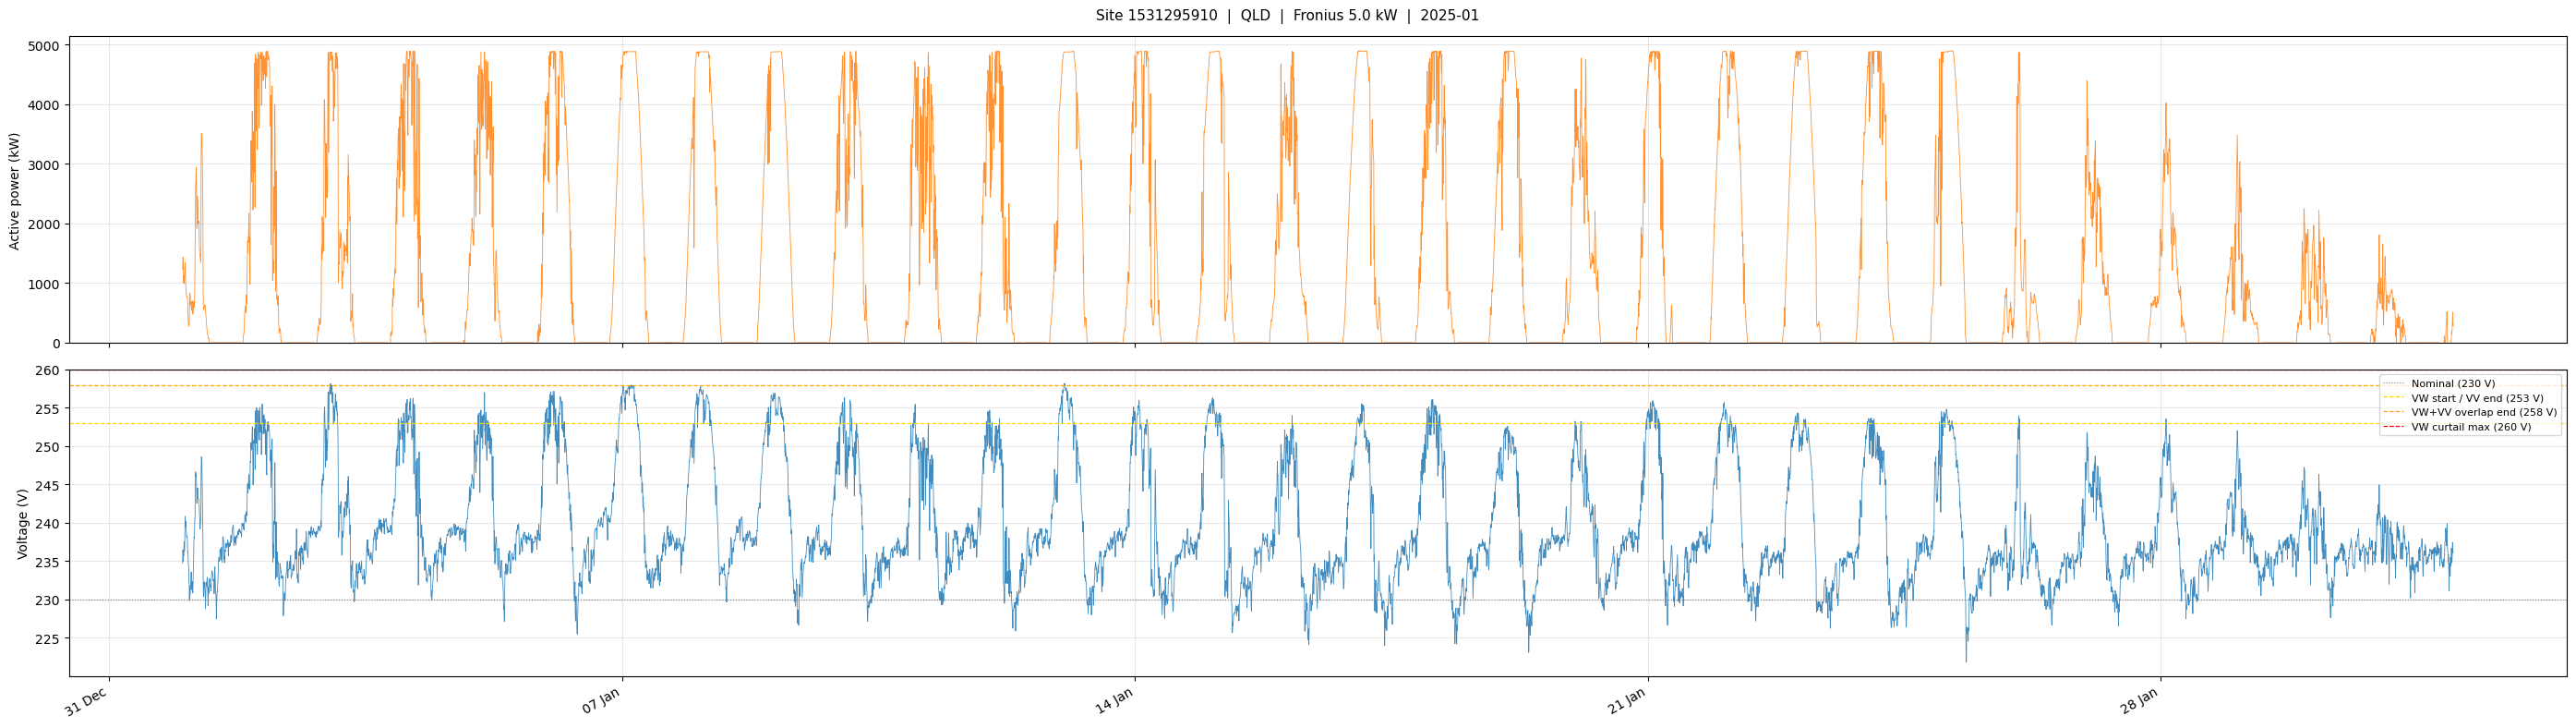

In [32]:
# -----------------------------------------------------------------------------
# Step 3: plot one panel per metric, extendable.
#
# To add a new panel:
#   1. Change `n_panels` to 3 (or more)
#   2. Copy one of the ax blocks below and point it at a different column
#      e.g. df["power_factor"], df["energy_reactive"], df["current"]
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n_panels = 2                               # <-- change to add panels
metrics  = ["power", "voltage"]            # <-- add column names here
colours  = ["tab:orange", "tab:blue"]
ylabels  = ["Active power (kW)", "Voltage (V)"]

fig, axes = plt.subplots(n_panels, 1, figsize=(28, 4 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

fig.suptitle(
    f"Site {chosen_site_id}  |  {candidate['state'].iloc[0]}  |  "
    f"{candidate['manufacturer'].iloc[0]} {candidate['ac_capacity_kw'].iloc[0]:.1f} kW  |  "
    f"{YEAR}-{MONTH:02d}",
    fontsize=11
)

for ax, metric, colour, ylabel in zip(axes, metrics, colours, ylabels):
    ax.plot(df["t_stamp"], df[metric],
            color=colour, linewidth=0.6, alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    # Add AS/NZS 4777.2:2020 voltage reference lines to every panel that
    # shows voltage — you can see exactly when the inverter enters each zone.
    if metric == "voltage":
        ax.axhline(230, color="gray",    lw=0.8, ls=":",  label="Nominal (230 V)")
        ax.axhline(253, color="gold",    lw=0.9, ls="--", label="VW start / VV end (253 V)")
        ax.axhline(258, color="orange",  lw=0.9, ls="--", label="VW+VV overlap end (258 V)")
        ax.axhline(260, color="red",     lw=0.9, ls="--", label="VW curtail max (260 V)")
        ax.legend(fontsize=8, loc="upper right")

    if metric == "power":
        ax.set_ylim(bottom=0)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

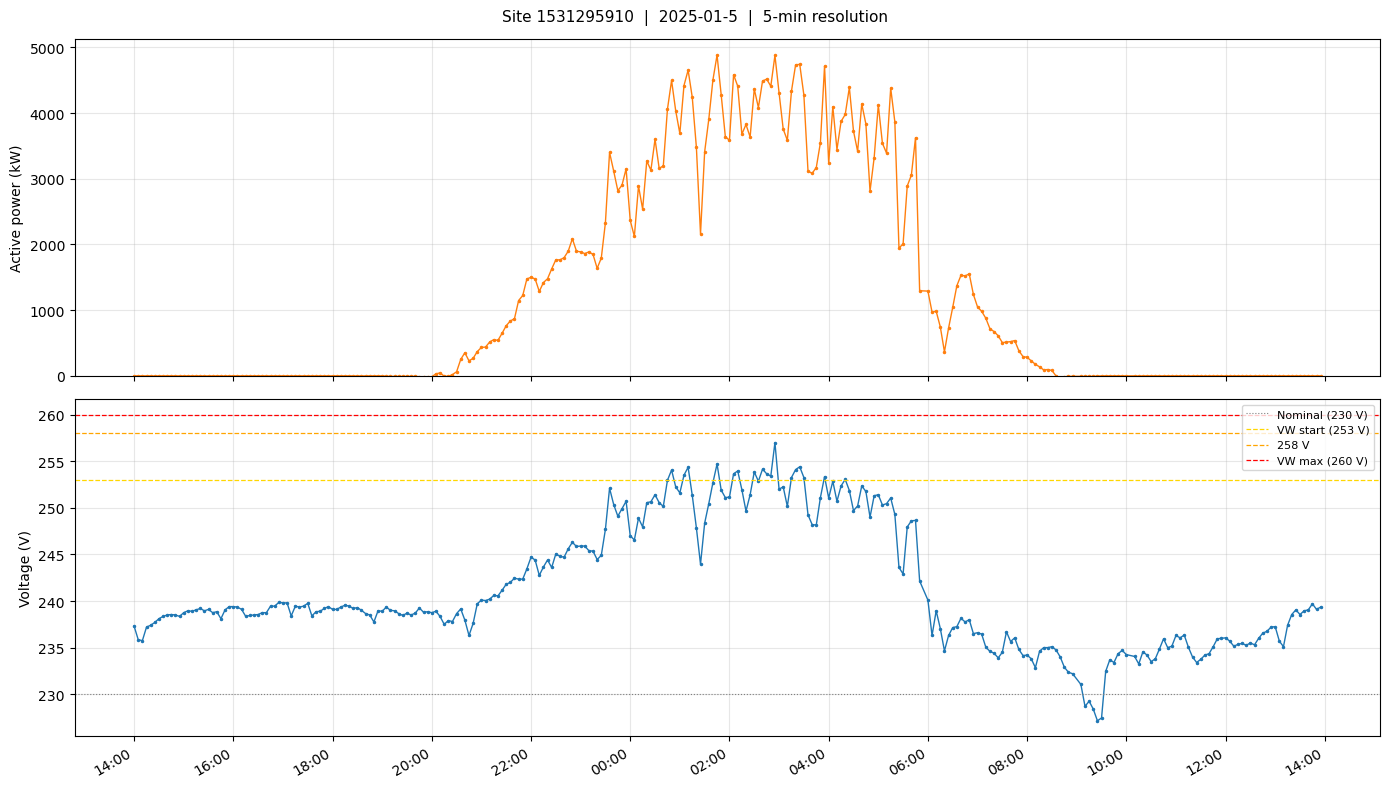

In [33]:
# -----------------------------------------------------------------------------
# Step 4: zoom into a single day (no re-query uses df already in memory).
# Change zoom_date to any date within the month pulled above.
# -----------------------------------------------------------------------------

zoom_date = f"{YEAR}-{MONTH:02d}-5"       # <-- Date here!

mask   = df["t_stamp_aest"].dt.date == pd.Timestamp(zoom_date).date()
df_day = df[mask]

if df_day.empty:
    print(f"No data for {zoom_date}. Try another date.")
    print("Dates with data:", df["t_stamp_aest"].dt.date.unique()[:10])
else:
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 4 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]

    fig.suptitle(
        f"Site {chosen_site_id}  |  {zoom_date}  |  5-min resolution",
        fontsize=11
    )

    for ax, metric, colour, ylabel in zip(axes, metrics, colours, ylabels):
        ax.plot(df_day["t_stamp_aest"], df_day[metric],
                color=colour, marker=".", markersize=3, linewidth=1)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        if metric == "voltage":
            ax.axhline(230, color="gray",   lw=0.8, ls=":",  label="Nominal (230 V)")
            ax.axhline(253, color="gold",   lw=0.9, ls="--", label="VW start (253 V)")
            ax.axhline(258, color="orange", lw=0.9, ls="--", label="258 V")
            ax.axhline(260, color="red",    lw=0.9, ls="--", label="VW max (260 V)")
            ax.legend(fontsize=8, loc="upper right")

        if metric == "power":
            ax.set_ylim(bottom=0)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()